In [56]:
# --- Data & Yahoo Finance ---
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- TFT & time series forecasting (PyTorch) ---
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
# from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters  # optional

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Preprocessing & metrics ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Utilities ---
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [57]:
# ── Load raw files ─────────────────────────────────────────────────────────────
top50 = pd.read_csv("top50_adjclose_2010_2025.csv", parse_dates=["Date"])
unp   = pd.read_csv("unp_us_d.csv",                 parse_dates=["Date"])
spx   = pd.read_csv("^spx_d.csv",                    parse_dates=["Date"])

top50 = top50[["Date", "AAPL", "JPM", "XOM", "JNJ"]].copy()
unp   = unp[["Date", "Close"]].rename(columns={"Close": "UNP"})
spx   = spx[["Date", "Close"]].rename(columns={"Close": "SPX"})

# ── Merge everything on Date (inner join = common trading days only) ────────────
df = top50.merge(unp, on="Date", how="inner") \
          .merge(spx, on="Date", how="inner")

# ── Filter to 2015-01-01 → last date where ALL sources have data ───────────────
df = df[df["Date"] >= "2015-01-01"].reset_index(drop=True)

df = df.set_index("Date")

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range : 2015-01-02 → 2025-12-30
Trading days: 2765
Columns     : ['AAPL', 'JPM', 'XOM', 'JNJ', 'UNP', 'SPX']
Missing values:
AAPL    0
JPM     0
XOM     0
JNJ     0
UNP     0
SPX     0
dtype: int64
                 AAPL        JPM        XOM        JNJ      UNP      SPX
Date                                                                    
2015-01-02  24.237549  46.511147  57.916904  76.955574  99.4006  2058.20
2015-01-05  23.554741  45.067200  56.332180  76.418091  96.0670  2020.58
2015-01-06  23.556957  43.898647  56.032707  76.042587  94.0529  2002.61


In [58]:
TICKERS = ["AAPL", "JPM", "XOM", "JNJ", "UNP"]

# ── Log returns ────────────────────────────────────────────────────────────────
for t in TICKERS:
    df[f"{t}_ret"] = np.log(df[t] / df[t].shift(1))

df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

# ── Rolling MAs of log returns (per stock only, as per proposal) ───────────────
for t in TICKERS:
    df[f"{t}_MA5"]  = df[f"{t}_ret"].rolling(5).mean()
    df[f"{t}_MA21"] = df[f"{t}_ret"].rolling(21).mean()
    df[f"{t}_MA63"] = df[f"{t}_ret"].rolling(63).mean()

# ── Rolling volatility of log returns (per stock only) ────────────────────────
for t in TICKERS:
    df[f"{t}_VOL5"]  = df[f"{t}_ret"].rolling(5).std()
    df[f"{t}_VOL21"] = df[f"{t}_ret"].rolling(21).std()
    df[f"{t}_VOL63"] = df[f"{t}_ret"].rolling(63).std()

# ── Shared SPX rolling volatility ─────────────────────────────────────────────
df["SPX_VOL21"] = df["SPX_ret"].rolling(21).std()

# ── Drop raw prices (no longer needed) and first 63 rows (NaN warmup) ─────────
price_cols = TICKERS + ["SPX"]
df = df.drop(columns=price_cols)
df = df.iloc[63:].copy()

# ── Reorder columns: SPX shared features first, then per-stock blocks ──────────
spx_cols    = ["SPX_ret", "SPX_VOL21"]
stock_cols  = [f"{t}{s}" for t in TICKERS 
               for s in ["_ret", "_MA5", "_MA21", "_MA63", "_VOL5", "_VOL21", "_VOL63"]]

df = df[spx_cols + stock_cols]

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Date range  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Missing values:\n{df.isna().sum()}")
print(df.head(3))

Date range  : 2015-04-06 → 2025-12-30
Trading days: 2702
Columns     : ['SPX_ret', 'SPX_VOL21', 'AAPL_ret', 'AAPL_MA5', 'AAPL_MA21', 'AAPL_MA63', 'AAPL_VOL5', 'AAPL_VOL21', 'AAPL_VOL63', 'JPM_ret', 'JPM_MA5', 'JPM_MA21', 'JPM_MA63', 'JPM_VOL5', 'JPM_VOL21', 'JPM_VOL63', 'XOM_ret', 'XOM_MA5', 'XOM_MA21', 'XOM_MA63', 'XOM_VOL5', 'XOM_VOL21', 'XOM_VOL63', 'JNJ_ret', 'JNJ_MA5', 'JNJ_MA21', 'JNJ_MA63', 'JNJ_VOL5', 'JNJ_VOL21', 'JNJ_VOL63', 'UNP_ret', 'UNP_MA5', 'UNP_MA21', 'UNP_MA63', 'UNP_VOL5', 'UNP_VOL21', 'UNP_VOL63']
Missing values:
SPX_ret       0
SPX_VOL21     0
AAPL_ret      0
AAPL_MA5      0
AAPL_MA21     0
AAPL_MA63     0
AAPL_VOL5     0
AAPL_VOL21    0
AAPL_VOL63    0
JPM_ret       0
JPM_MA5       0
JPM_MA21      0
JPM_MA63      0
JPM_VOL5      0
JPM_VOL21     0
JPM_VOL63     0
XOM_ret       0
XOM_MA5       0
XOM_MA21      0
XOM_MA63      0
XOM_VOL5      0
XOM_VOL21     0
XOM_VOL63     0
JNJ_ret       0
JNJ_MA5       0
JNJ_MA21      0
JNJ_MA63      0
JNJ_VOL5      0
JNJ_VOL21    

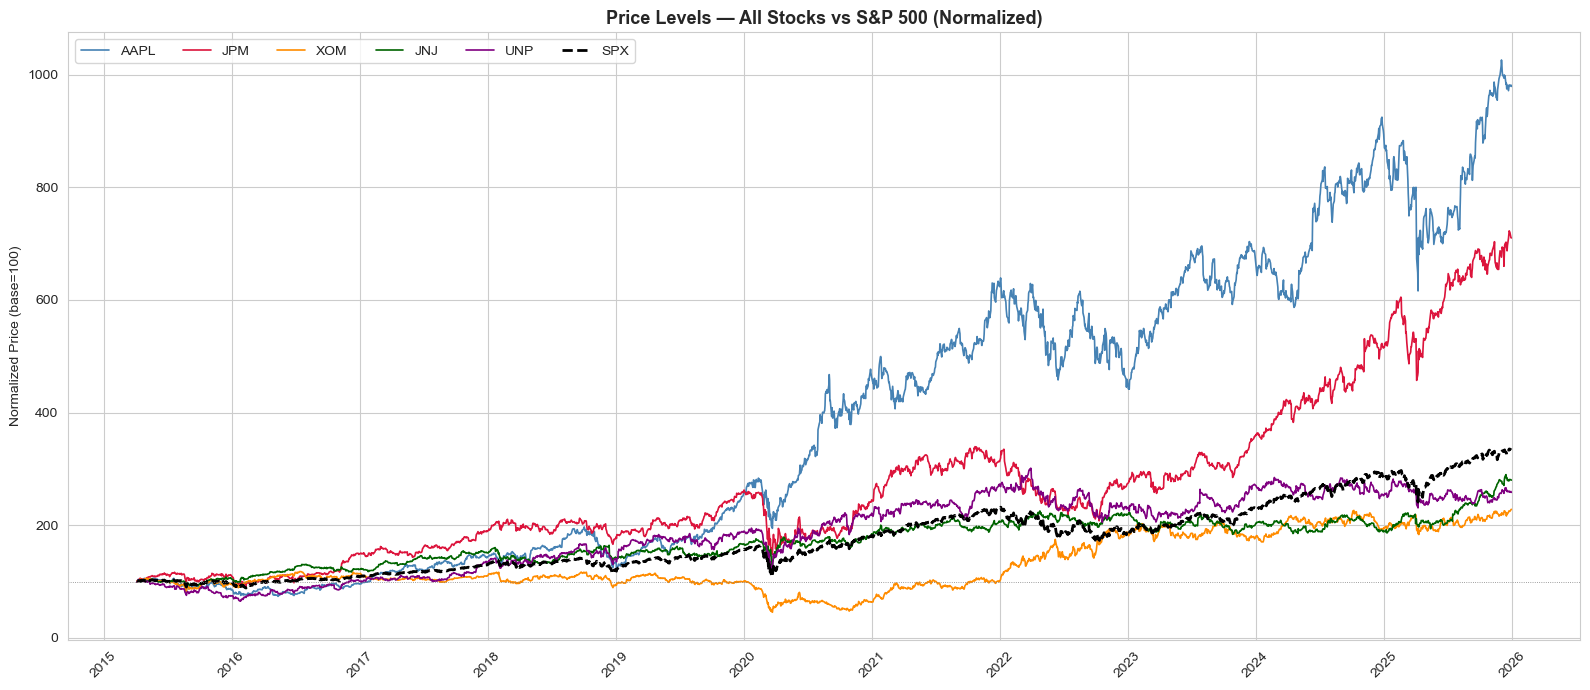

In [59]:
ALL_TICKERS = TICKERS + ["SPX"]

prices_norm = df[[f"{t}_ret" for t in ALL_TICKERS]].cumsum().apply(np.exp) * 100
prices_norm.columns = ALL_TICKERS

fig, ax = plt.subplots(figsize=(16, 7))

colors = {"AAPL":"steelblue", "JPM":"crimson", "XOM":"darkorange",
          "JNJ":"darkgreen",  "UNP":"purple",  "SPX":"black"}

for col in ALL_TICKERS:
    lw = 2.0 if col == "SPX" else 1.2
    ls = "--" if col == "SPX" else "-"
    ax.plot(prices_norm.index, prices_norm[col], label=col,
            color=colors[col], lw=lw, linestyle=ls)

ax.axhline(100, color="grey", lw=0.6, linestyle=":")
ax.set_ylabel("Normalized Price (base=100)", fontsize=10)
ax.set_title("Price Levels — All Stocks vs S&P 500 (Normalized)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=6, loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

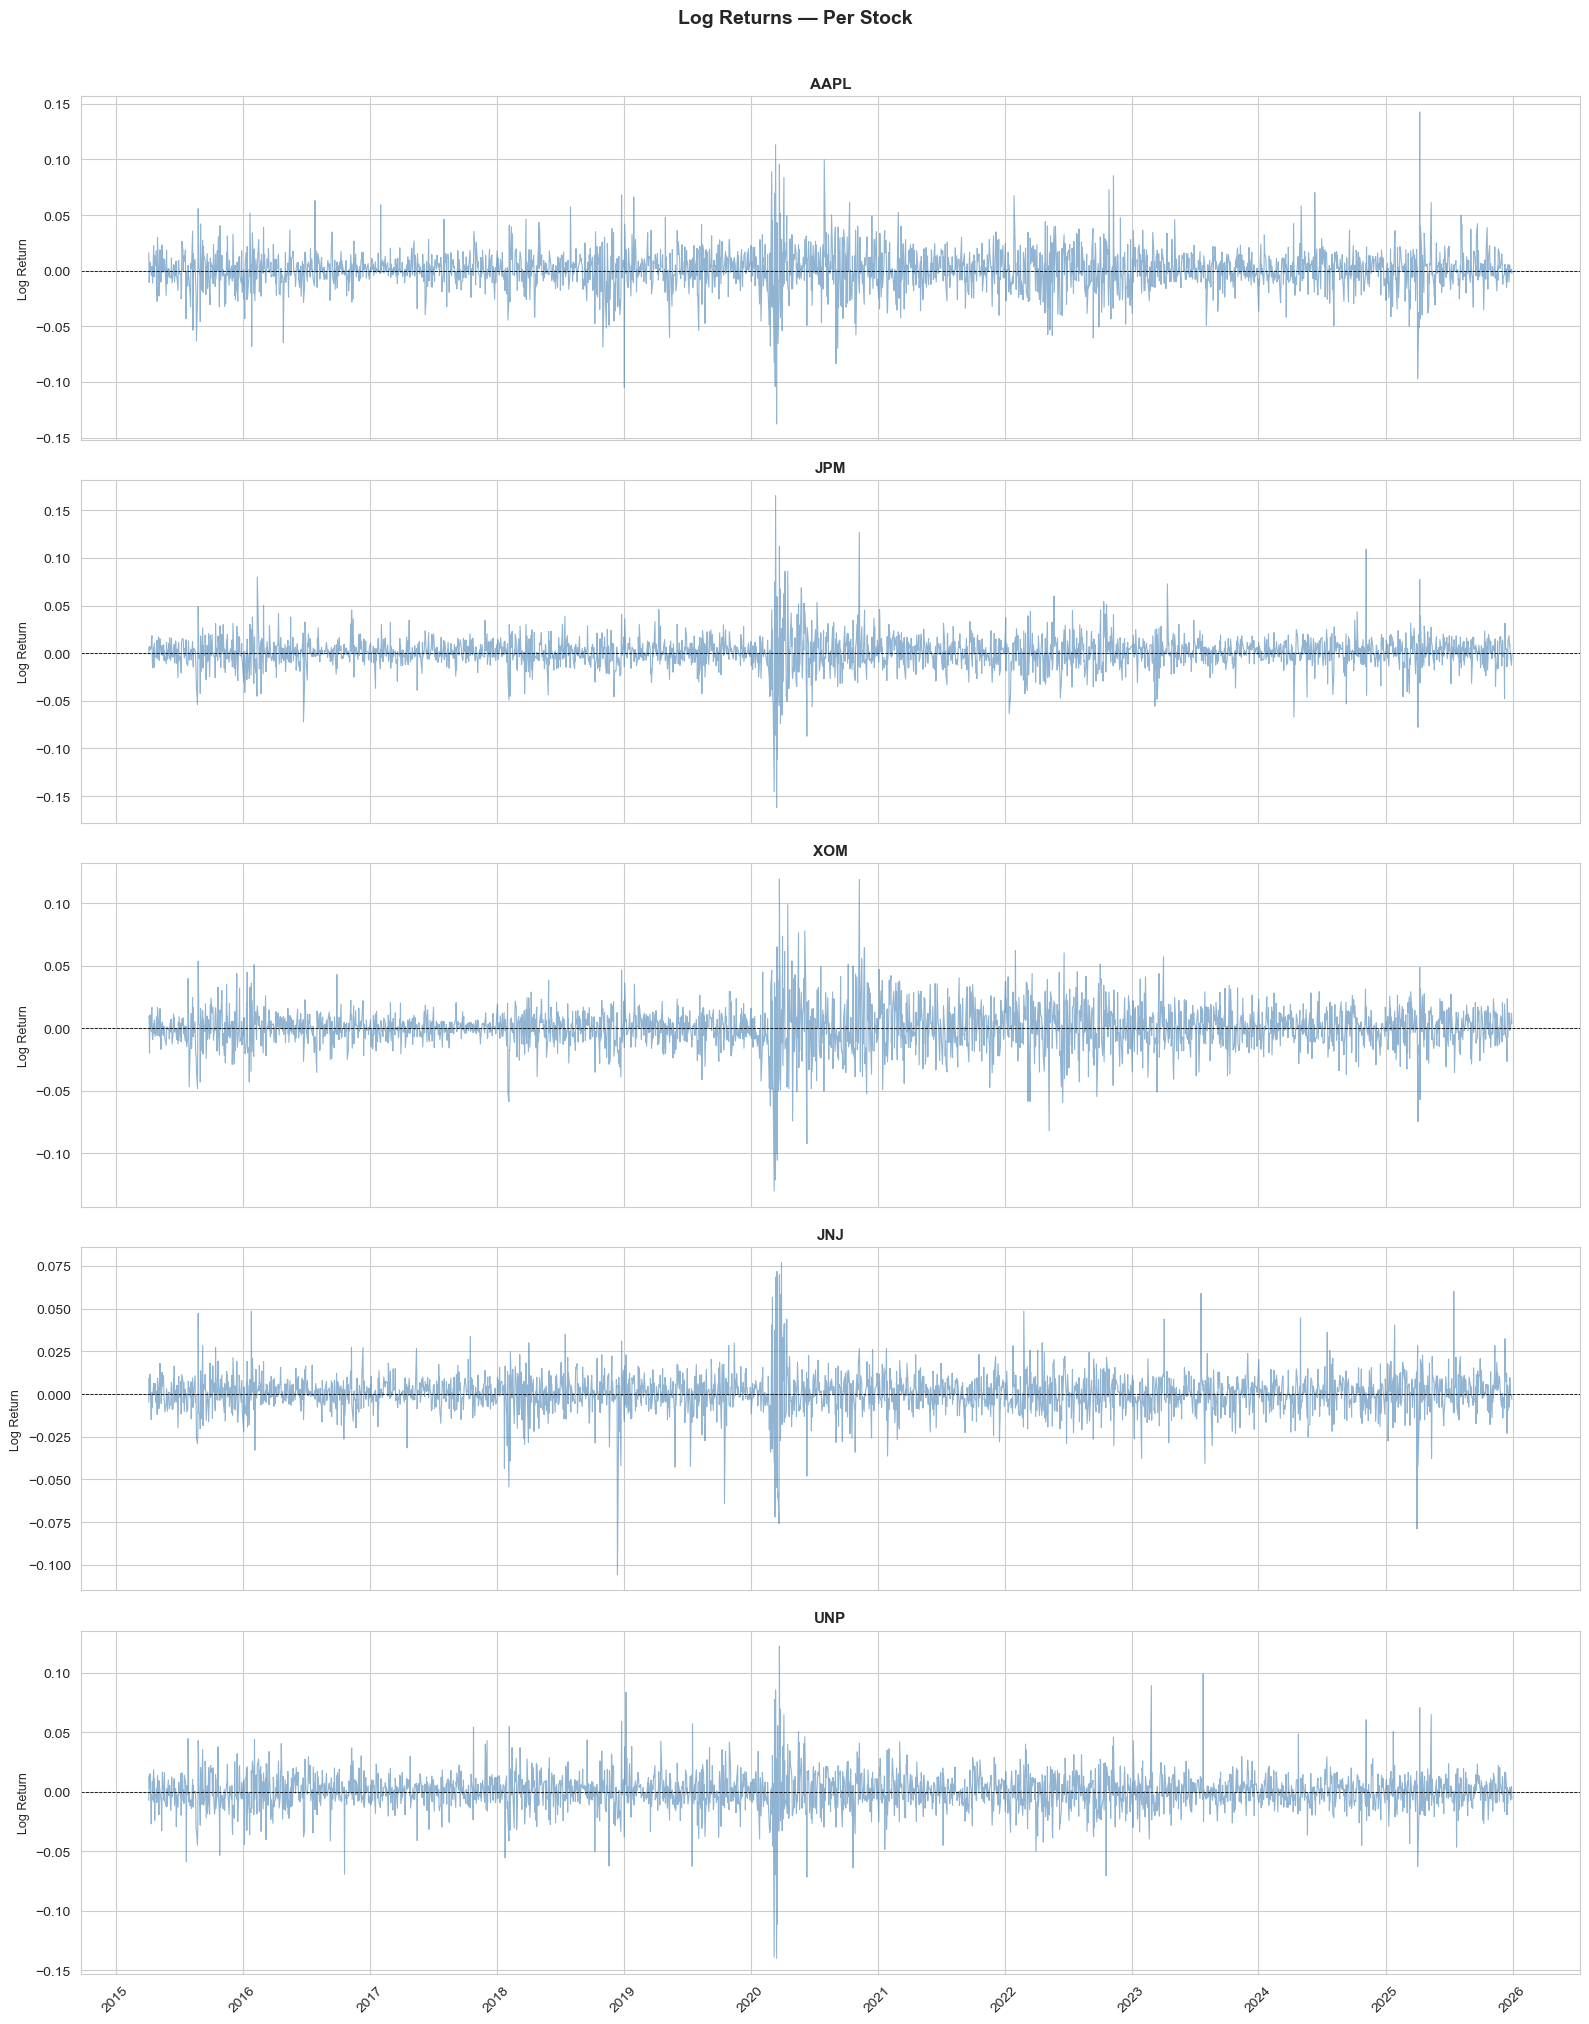

In [60]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, t in zip(axes, TICKERS):
    ax.plot(df.index, df[f"{t}_ret"], color="steelblue", alpha=0.6, lw=0.8, label="Log Return")
    ax.axhline(0, color="black", lw=0.6, linestyle="--")
    ax.set_ylabel("Log Return", fontsize=9)
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Log Returns — Per Stock", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDescriptive stats:\n", df.describe())

Shape: (2702, 37)

Descriptive stats:
            SPX_ret    SPX_VOL21     AAPL_ret     AAPL_MA5    AAPL_MA21  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000   
mean      0.000446     0.009458     0.000844     0.000846     0.000849   
std       0.011364     0.006419     0.018181     0.007708     0.003767   
min      -0.127652     0.002185    -0.137708    -0.051618    -0.015928   
25%      -0.003747     0.005775    -0.007270    -0.003376    -0.001389   
50%       0.000710     0.007815     0.000898     0.001260     0.001128   
75%       0.005735     0.011659     0.009841     0.005363     0.003496   
max       0.090895     0.061454     0.142617     0.033803     0.014691   

         AAPL_MA63    AAPL_VOL5   AAPL_VOL21   AAPL_VOL63      JPM_ret  ...  \
count  2702.000000  2702.000000  2702.000000  2702.000000  2702.000000  ...   
mean      0.000852     0.015281     0.016443     0.017052     0.000725  ...   
std       0.002142     0.010267     0.007893     0.006478